# Chargement des données

In [1]:
import duckdb
%load_ext sql

In [2]:
%sql duckdb:///../data/istex-search-metadata.db

Connecting to 'duckdb:///../data/istex-search-metadata.db'

## Echantillonnage

## Records

In [5]:
%%sql
SELECT
  *
FROM
  records USING SAMPLE 1000 (reservoir);

Running query in 'duckdb:///../data/istex-search-metadata.db'

arkIstex,corpusName,genre,language,publicationDate,accessCondition,hostTitle,pdfWordCount,pdfCharCount,pdfVersion,pdfPageCount,pdfPageSize,pdfWordsPerPage,pdfText
ark:/67375/WNG-X5F82HQ9-7,wiley,abstract,eng,1999,closed,ChemInform,88,557,1.4,1,595.276 x 841.89 pts (A4),88,False
ark:/67375/6H6-F3CVZL2F-8,elsevier,other,eng,2017,closed,Cancer Letters,323,1902,1.7,1,595.276 x 793.701 pts,323,True
ark:/67375/6H6-KNXRB4B3-2,elsevier,other,eng,2012,bronzeOpenAccess,The Lancet,858,4750,1.7,1,612 x 792 pts (letter),858,True
ark:/67375/6H6-4FZ0KDHC-J,elsevier,abstract,eng,2017,bronzeOpenAccess,Radiotherapy and Oncology,1089,6581,1.7,2,595 x 842 pts (A4),545,True
ark:/67375/6H6-R4M9PXQL-L,elsevier,research-article,eng,2018,closed,Mechanisms of Ageing and Development,4228,23272,1.7,6,595.276 x 793.701 pts,705,True
ark:/67375/1BB-SKMKZNX6-N,springer-journals,research-article,ger,1980,closed,Langenbecks Archiv für Chirurgie,3154,11821,1.3,8,468 x 684 pts,394,True
ark:/67375/6GQ-0D4WW587-3,cambridge,research-article,eng,1984,closed,Behavioral and Brain Sciences,42821,224715,1.5,36,597.6 x 871.2 pts,1189,True
ark:/67375/VQC-0Q0P1NWT-B,springer-journals,research-article,eng,2013,closed,BIT Numerical Mathematics,7251,28976,1.4,16,439.37 x 666.142 pts,453,True
ark:/67375/2M2-265CZ90M-T,oa-plos,research-article,eng,2017,goldOpenAccess,PLOS Computational Biology,7933,47749,1.6,16,612 x 792 pts (letter),496,True
ark:/67375/80W-GHJV4SWP-M,edp-sciences,research-article,eng,2019,bronzeOpenAccess,Astronomy & Astrophysics,11771,56555,1.3,16,595.276 x 841.89 pts (A4),736,True


## Metadata

In [6]:
%%sql
SELECT
  *
FROM
  metadata USING SAMPLE 1000 (reservoir);

Running query in 'duckdb:///../data/istex-search-metadata.db'

arkIstex,path,original,mime
ark:/67375/6H6-FF6B4W4D-6,4A67DB29DC331A7C6B620232636A7B453EB032C9.mods.xml,False,application/mods+xml
ark:/67375/WNG-V7FCBR1L-0,CAMH.CAMH582_2.xml,True,application/xml
ark:/67375/WNG-KFRSDKST-G,APP.APP070291216.xml,True,application/xml
ark:/67375/WNG-X066ZZWR-D,BJOP.BJOP1262.xml,True,application/xml
ark:/67375/VQC-SLVVR57P-4,DBC7DADFD50FDC53CE5ABCE8B8BE0A66D40EA435.mods.xml,False,application/mods+xml
ark:/67375/HXZ-05W75RMD-5,120001.xml,True,application/xml
ark:/67375/WNG-83RZRT26-S,228BE90994AE041563D61F49CB6F28247C94704A.mods.xml,False,application/mods+xml
ark:/67375/6H6-G8HHBPTW-F,main.xml,True,application/xml
ark:/67375/WNG-PN59H64W-M,JCCM.JCCM113.xml,True,application/xml
ark:/67375/TPS-7ZDBX4TH-P,jo00221a035.jatsxml,True,application/xml


# Analyse

In [8]:
%%sql
SELECT
  COUNT(*) AS "Documents créés par la chaine d'ingestion Istex"
FROM
  (
    SELECT
      "path"
    FROM
      metadata
    WHERE
      original = FALSE
    UNION ALL
    SELECT
      "path"
    FROM
      fulltext
    WHERE
      original = FALSE
  );

Running query in 'duckdb:///../data/istex-search-metadata.db'

Documents créés par la chaine d'ingestion Istex
141755942


In [9]:
%%sql

WITH cte_extension_fulltext AS (
    SELECT 'fulltext' AS "type", LOWER(string_split(path, '.')[-1]) AS extension FROM fulltext
),
cte_extension_metadata AS (
    SELECT 'metadata' AS "type", LOWER(string_split(path, '.')[-1]) AS extension FROM metadata
),
cte_extension AS (
    SELECT * FROM cte_extension_fulltext
    UNION ALL
    SELECT * FROM cte_extension_metadata
)
    
SELECT extension, type, COUNT(*) AS "Nombre de fichiers" FROM cte_extension
GROUP BY extension, type;

Running query in 'duckdb:///../data/istex-search-metadata.db'

extension,type,Nombre de fichiers
txt,fulltext,31701201
nxml,metadata,58918
meta,metadata,4841454
pdf,fulltext,32041134
json,metadata,649074
zip,fulltext,26787568
xml,fulltext,31911409
jatsxml,metadata,816239
cleaned,fulltext,18060927
tif,fulltext,40356968


# Analyse statistique à faire sur les fichiers OCR produits par Istex

* OCR / par décénnies
* OCR par disciplines
* OCR par langue

# Données à récupérer dans l'API Istex

* Si pas de texte transparent
* Si pas d'image

arkIstex
genre -> du document
language -> du document
publicationDate
accessCondition.value (on pourra inférer le accessCondition.contentType au besoin)
corpusName
metadata ->  ark, path, mime, orignal
fulltext -> ark, path, mime, orignal

## Analyse fichier PDF

10 % du fichier PDF arrodi à l'entier supérieur. Selection aléatoire pour éviter de tomber sur des pages d'annexes

### Au niveau de chaque page (ou d'un échantillon de page)

* Liste des images et page sur laquelle a été trouvée l'image + taille de l'image + taille de la page
* Présence de texte transparent -> compter le nombre de caractères (pour faire des ratios) ? 
* Présence de texte pas transparent -> compter le nombre de caractères
* Présence de texte très fragmenté (Tj) 
* Taille de police unique

* Pourquoi 10% ?
* Graine pour le choix aléatoire des pages.
* Passer tout UK-19 PARLIAMENT
* Autoriser la reprise du script

In [ ]:
%config SqlMagic.displaylimit = 100

In [10]:
%%sql
SELECT
  *
FROM
  fulltext
  JOIN records USING (arkIstex)
WHERE
  PATH LIKE '%.ocr';

Running query in 'duckdb:///../data/istex-search-metadata.db'

arkIstex,path,original,mime,corpusName,genre,language,publicationDate,accessCondition,hostTitle,pdfWordCount,pdfCharCount,pdfVersion,pdfPageCount,pdfPageSize,pdfWordsPerPage,pdfText
ark:/67375/WNG-K6V6GBBS-3,88CE6CA9C23F351709D9E28D08A967790024CA0A-istex-1560504994802.ocr,False,text/plain,wiley,abstract,eng,1995,closed,ChemInform,126,653,1.4,2,595.276 x 841.89 pts (A4),63,False
ark:/67375/WNG-K6V7QG18-S,DEDF38270D85B051415A8A59B1CE322F9D15BFBE-istex-1560488873968.ocr,False,text/plain,wiley,abstract,eng,2001,closed,ChemInform,108,626,1.4,1,595.276 x 841.89 pts (A4),108,False
ark:/67375/WNG-K6V8FF3K-M,4E6A6F83250719EB1FE50376D20CC3A2434B045C-istex-1560456886283.ocr,False,text/plain,wiley,abstract,eng,2002,closed,ChemInform,82,504,1.4,1,595.276 x 841.89 pts (A4),82,False
ark:/67375/WNG-K6V9W69Q-H,747D28710F8517A626ABE24F62113ACB40FA1BFD-istex-1571259723902.ocr,False,text/plain,wiley,other,ger,2000,bronzeOpenAccess,Nachrichten aus der Chemie,290,2144,1.3,1,648 x 863.759 pts,290,True
ark:/67375/WNG-K6VBGG8W-5,3B9F2D77B62BB05E1220D3A1FBDFDB7325BAB57D-istex-1489627933805.ocr,False,text/plain,wiley,other,eng,1994,closed,Ibis,0,0,1.3,1,576 x 792 pts,0,False
ark:/67375/WNG-K6VBLV4J-M,6351857742011711DE203F78A568AA1627CC44F3-istex-1568915660173.ocr,False,text/plain,wiley,other,eng,1986,bronzeOpenAccess,Journal of the Science of Food and Agriculture,157,708,1.3,1,468 x 683.759 pts,157,True
ark:/67375/WNG-K6VDBVW5-L,3F0270B68C864459A00501409C1FD009A6A6003E-istex-1489610815208.ocr,False,text/plain,wiley,article,eng,1990,closed,Journal of Heterocyclic Chemistry,0,0,1.3,2,547 x 703 pts,0,False
ark:/67375/WNG-K6VDLG2C-5,20C0D5961D2C0D2553A63DBAD040B6131CFCA2D1-istex-1560384637699.ocr,False,text/plain,wiley,abstract,eng,2015,closed,ChemInform,66,402,1.5,1,417 x 590 pts,66,False
ark:/67375/WNG-K6VF5X17-T,F239061EC435A5A142B06B3D66789A04E93A079A-istex-1560426654236.ocr,False,text/plain,wiley,abstract,eng,2003,closed,ChemInform,76,431,1.3,1,416 x 589 pts,76,False
ark:/67375/WNG-K6VF9Z98-K,452AFC05D5022B73363CA506C75971ABB5AB351A-istex-1560433833906.ocr,False,text/plain,wiley,abstract,eng,2003,closed,ChemInform,94,513,1.3,1,417 x 590 pts,94,False


In [11]:
%%sql 
SELECT
  (CAST(publicationDate AS INTEGER) / / 10) * 10 AS decade,
  COUNT(*) AS nb_total,
  COUNT(*) FILTER (
    WHERE
      PATH LIKE '%.ocr'
  ) AS nb_ocr
FROM
  fulltext
  JOIN records USING (arkIstex)
WHERE
  TRY_CAST (publicationDate AS INTEGER) IS NOT NULL
  AND CAST(publicationDate AS INTEGER) >= 1800
  AND CAST(publicationDate AS INTEGER) < 2026
GROUP BY
  decade
ORDER BY
  decade;

Running query in 'duckdb:///../data/istex-search-metadata.db'

decade,nb_total,nb_ocr
1800,825183,155
1810,27878,139
1820,72990,1638
1830,126298,941
1840,186174,2045
1850,352103,2320
1860,386979,1977
1870,520832,14012
1880,672634,15691
1890,853459,17578


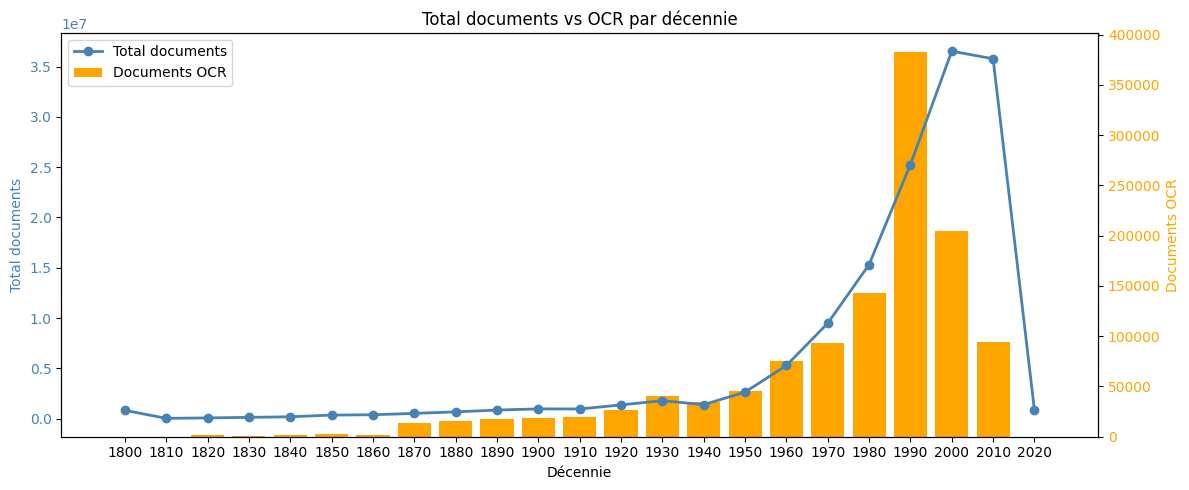

In [16]:
import matplotlib.pyplot as plt

df = _.DataFrame()
fig, ax1 = plt.subplots(figsize=(12, 5))

# Axe droit — barres OCR (créé en premier, dessiné en dessous)
ax2 = ax1.twinx()
ax2.bar(df['decade'], df['nb_ocr'], width=8, color='orange', alpha=1, label='Documents OCR')
ax2.set_ylabel('Documents OCR', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Axe gauche — ligne total (au-dessus)
ax1.set_zorder(ax2.get_zorder() + 1)  # ax1 passe devant ax2
ax1.patch.set_visible(False)           # rend le fond de ax1 transparent

ax1.plot(df['decade'], df['nb_total'], color='steelblue', marker='o', linewidth=2, label='Total documents')
ax1.set_xlabel('Décennie')
ax1.set_ylabel('Total documents', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(df['decade'], rotation=45)
plt.title('Total documents vs OCR par décennie')
plt.tight_layout()
plt.show()

In [53]:
%%sql
SELECT DISTINCT
  pdfPageCount
FROM
  records
ORDER BY
  pdfPageCount DESC;

Running query in 'duckdb:///../data/istex-search-metadata.db'

pdfPageCount
15171526
8323
5312
3500
3268
3144
3110
3099
3000
2926


## Répartition des pages

In [56]:
%%sql
SELECT
  histogram (pdfPageCount) AS page_histogram
FROM
  records;

Running query in 'duckdb:///../data/istex-search-metadata.db'

page_histogram


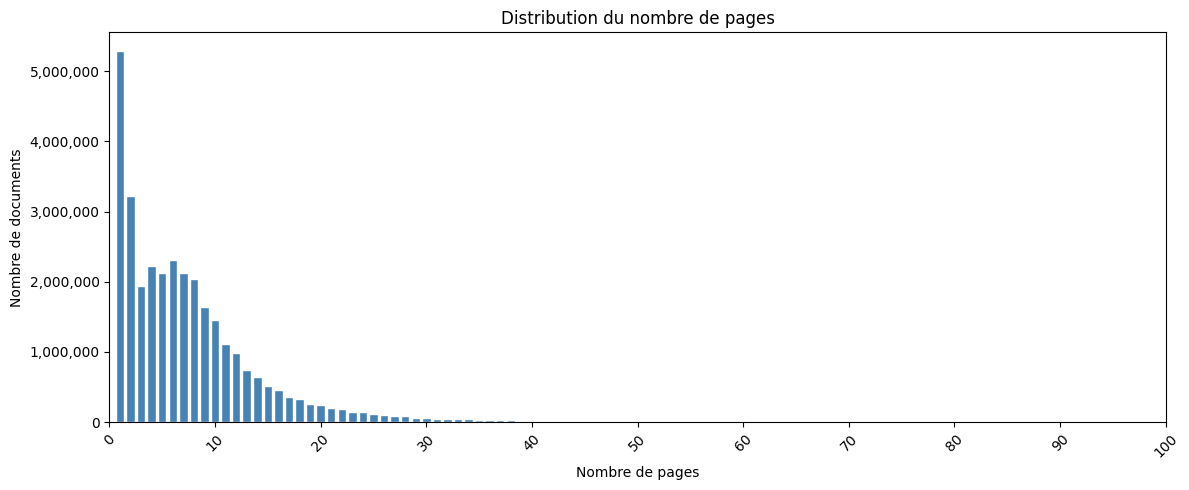

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

hist = _.DataFrame()['page_histogram'][0]

buckets = sorted(int(k) for k in hist.keys())
counts = [hist[int(b)] for b in buckets]

fig, ax = plt.subplots(figsize=(12,5))
width = (buckets[1] - buckets[0]) * 0.8

ax.bar(buckets, counts, width=width, color='steelblue', edgecolor='white')
ax.set_xlim(0, 100)
ax.set_xlabel("Nombre de pages")
ax.set_ylabel("Nombre de documents")
ax.set_title("Distribution du nombre de pages")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_xticks(range(0, 101, 10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()